In [ ]:
###Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
###Loading the dataset
df = pd.read_csv('../data/raw/HR_capstone_dataset.csv')

In [20]:
###Displaying the first few rows of the dataset
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [ ]:
###Data Exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [21]:
###Summary statistics of the dataset
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
###Data Cleaning and Preprocessing
df = df.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary', 'status'],
      dtype='str')

In [32]:
###Checking for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

df = df.drop_duplicates(keep='first')
print(f"Cleaned dataset shape: {df.shape}")

Number of duplicate rows: 0
Cleaned dataset shape: (11991, 10)


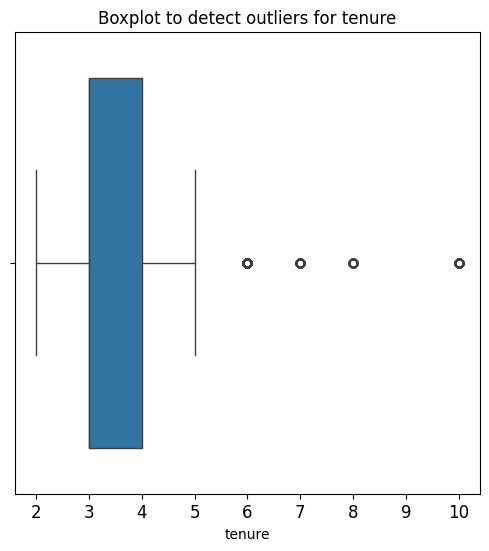

In [88]:
###Boxplot to detect outliers for tenure
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df['tenure'])
plt.show()

In [37]:
### Determine the number of rows containing outliers 
### YOUR CODE HERE ###

### Compute the 25th percentile value in `tenure`
percentile25 = df['tenure'].quantile(0.25)

### Compute the 75th percentile value in `tenure`
percentile75 = df['tenure'].quantile(0.75)

### Compute the interquartile range in `tenure`
iqr = percentile75 - percentile25

### Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

### Identify subset of data containing outliers in `tenure`
outliers = df[(df['tenure'] > upper_limit) | (df['tenure'] < lower_limit)]

### Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


left
0    10000
1     1991
Name: count, dtype: int64

Percentage distribution of 'left':
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


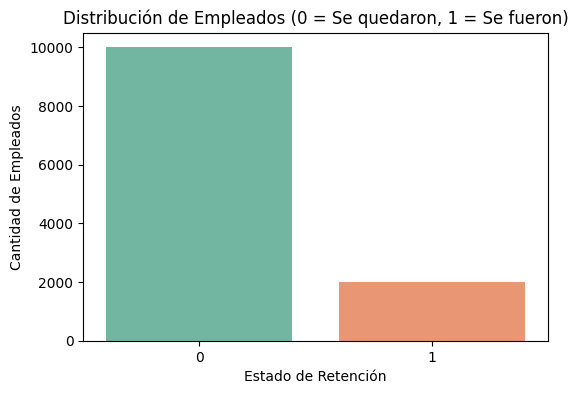

In [89]:
### Analyzing the target variable 'left'
print(df['left'].value_counts())
print("\nPercentage distribution of 'left':")
print(df['left'].value_counts(normalize=True) * 100)


### Charting the distribution of the target variable 'left'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='left', hue='left', palette='Set2', legend=False)
plt.title('Distribución de Empleados (0 = Se quedaron, 1 = Se fueron)')
plt.xlabel('Estado de Retención')
plt.ylabel('Cantidad de Empleados')
plt.show()

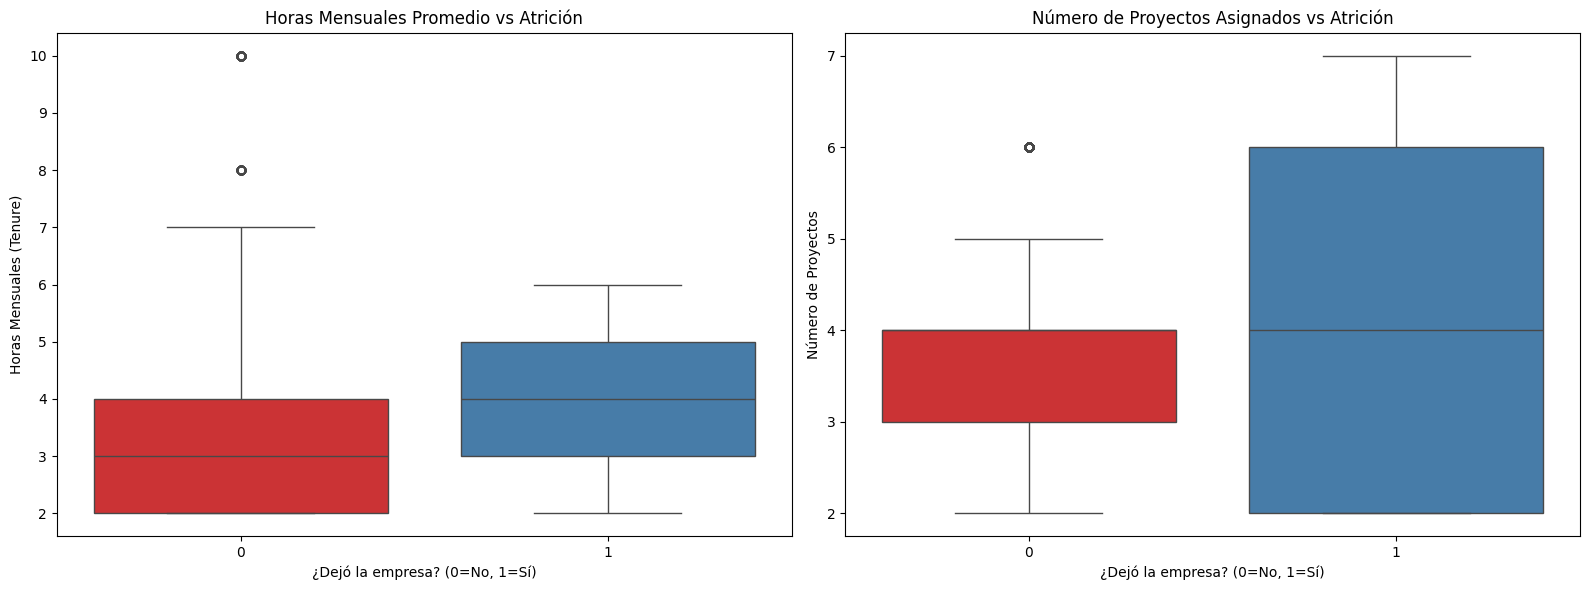

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot of Average Monthly Hours (Renamed to tenure) vs Attrition
sns.boxplot(data=df, x='left', y='tenure', hue='left', ax=ax[0], palette='Set1', legend=False)
ax[0].set_title('Horas Mensuales Promedio vs Atrición')
ax[0].set_xlabel('¿Dejó la empresa? (0=No, 1=Sí)')
ax[0].set_ylabel('Horas Mensuales (Tenure)')

# Boxplot of Number of Projects vs Attrition
sns.boxplot(data=df, x='left', y='number_project', hue='left', ax=ax[1], palette='Set1', legend=False)
ax[1].set_title('Número de Proyectos Asignados vs Atrición')
ax[1].set_xlabel('¿Dejó la empresa? (0=No, 1=Sí)')
ax[1].set_ylabel('Número de Proyectos')

plt.tight_layout()
plt.show()

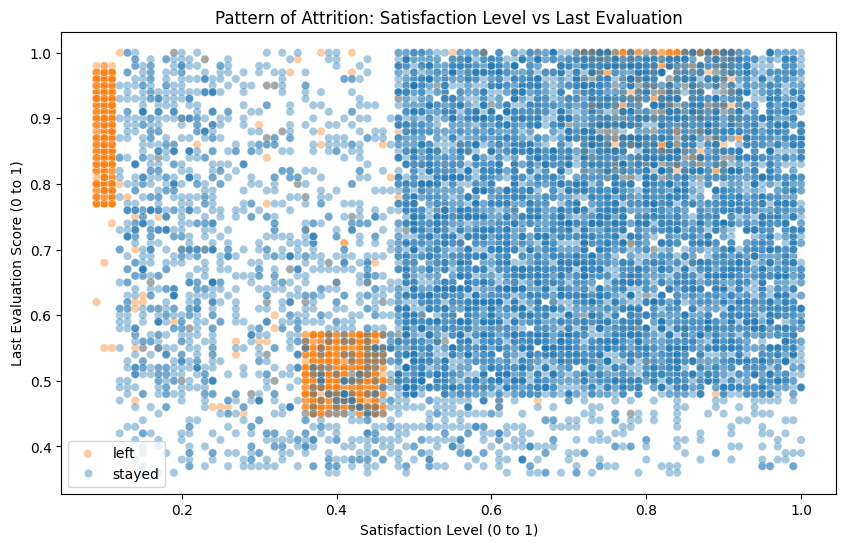

In [68]:
### Scatter plot of satisfaction level vs last evaluation, colored by attrition status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x='satisfaction_level', y='last_evaluation',hue='left',
    alpha=0.4
)
plt.title('Pattern of Attrition: Satisfaction Level vs Last Evaluation')
plt.xlabel('Satisfaction Level (0 to 1)')
plt.ylabel('Last Evaluation Score (0 to 1)')

# Cambiar etiquetas de la leyenda
plt.legend(labels=['left', 'stayed'])

plt.show()

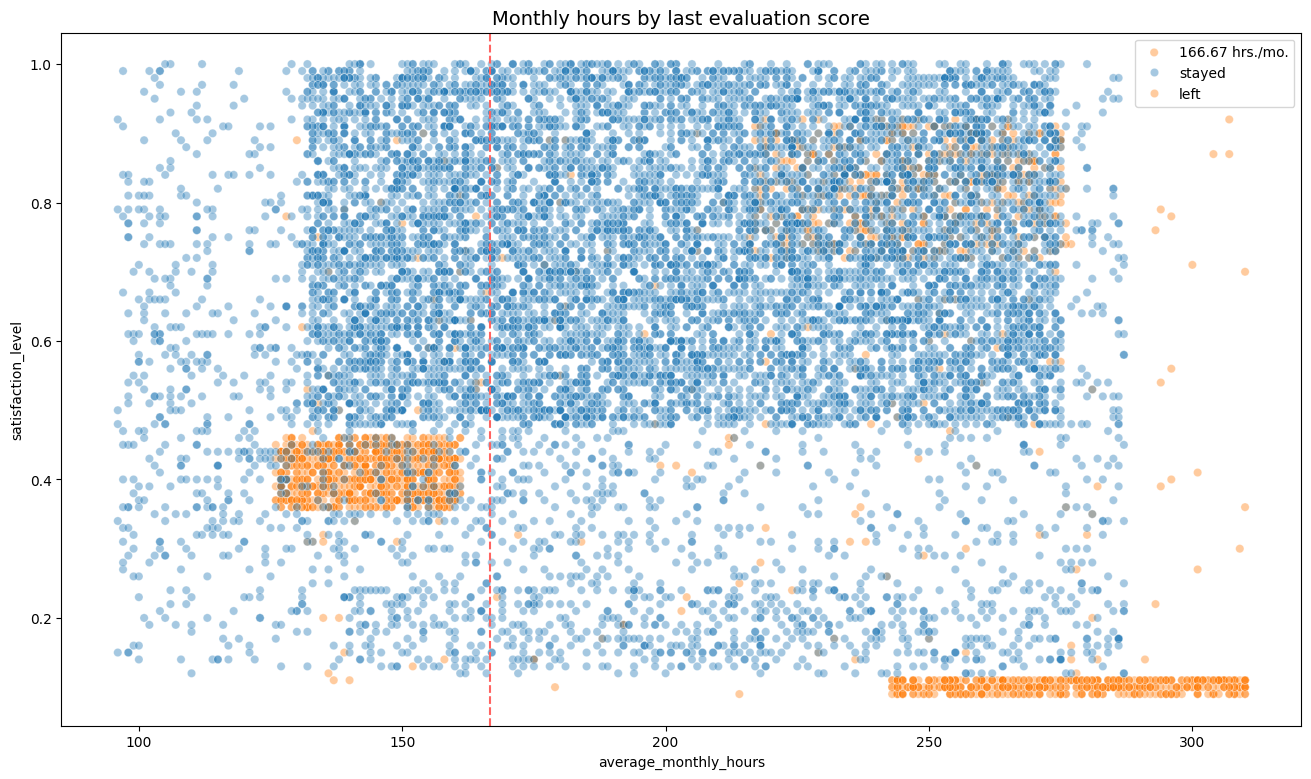

In [69]:
##scatterplot of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'stayed', 'left'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

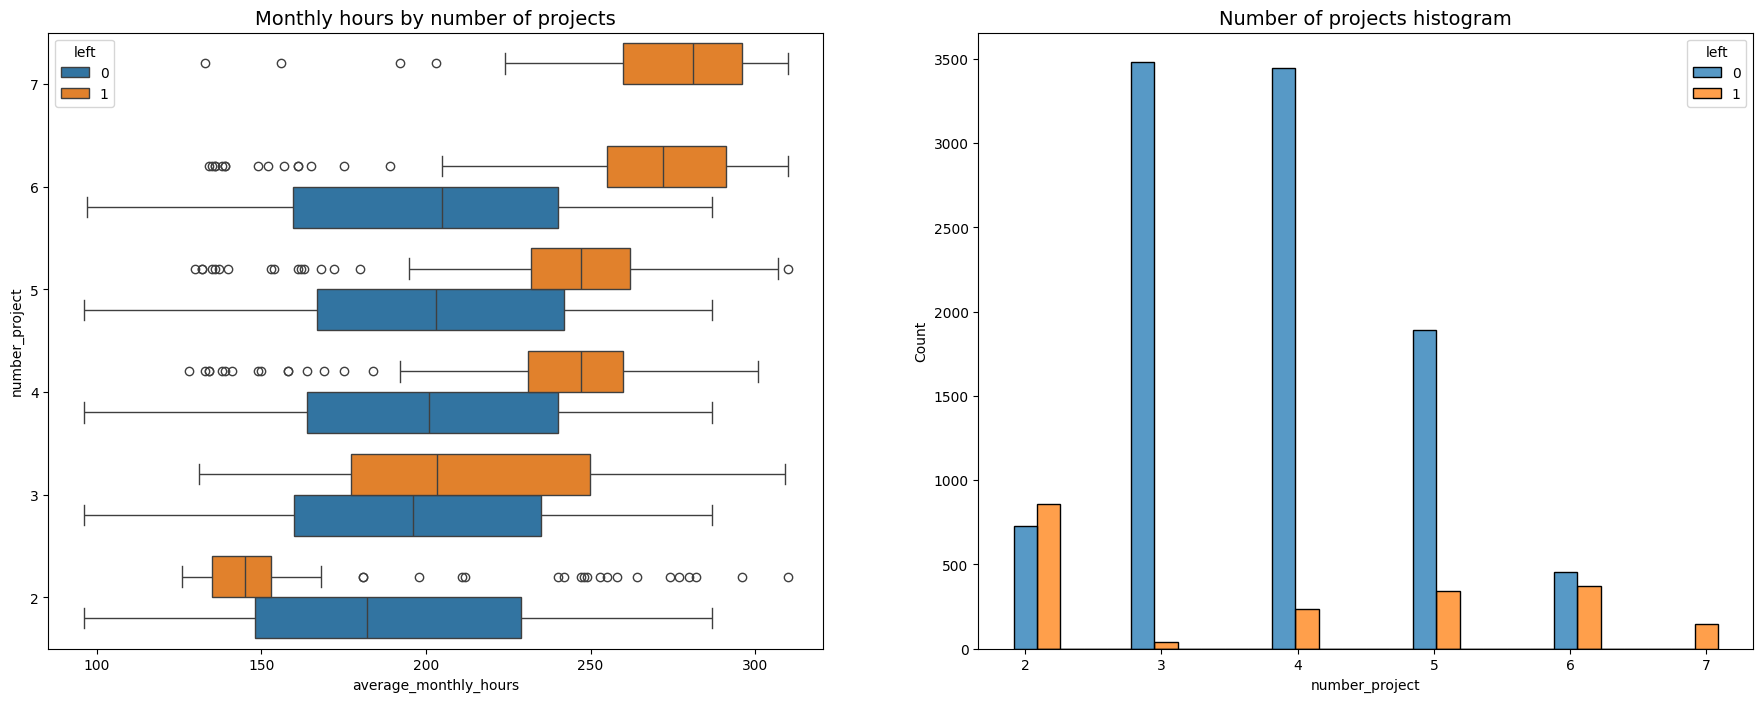

In [40]:

fig, ax = plt.subplots(1, 2, figsize = (22,8))

### Boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

### Histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df[df['left']==0]['number_project']
tenure_left = df[df['left']==1]['number_project']
sns.histplot(data=df, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')
plt.show()

In [70]:
###Summarize the mean and median satisfaction level for employees who stayed versus those who left
df.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


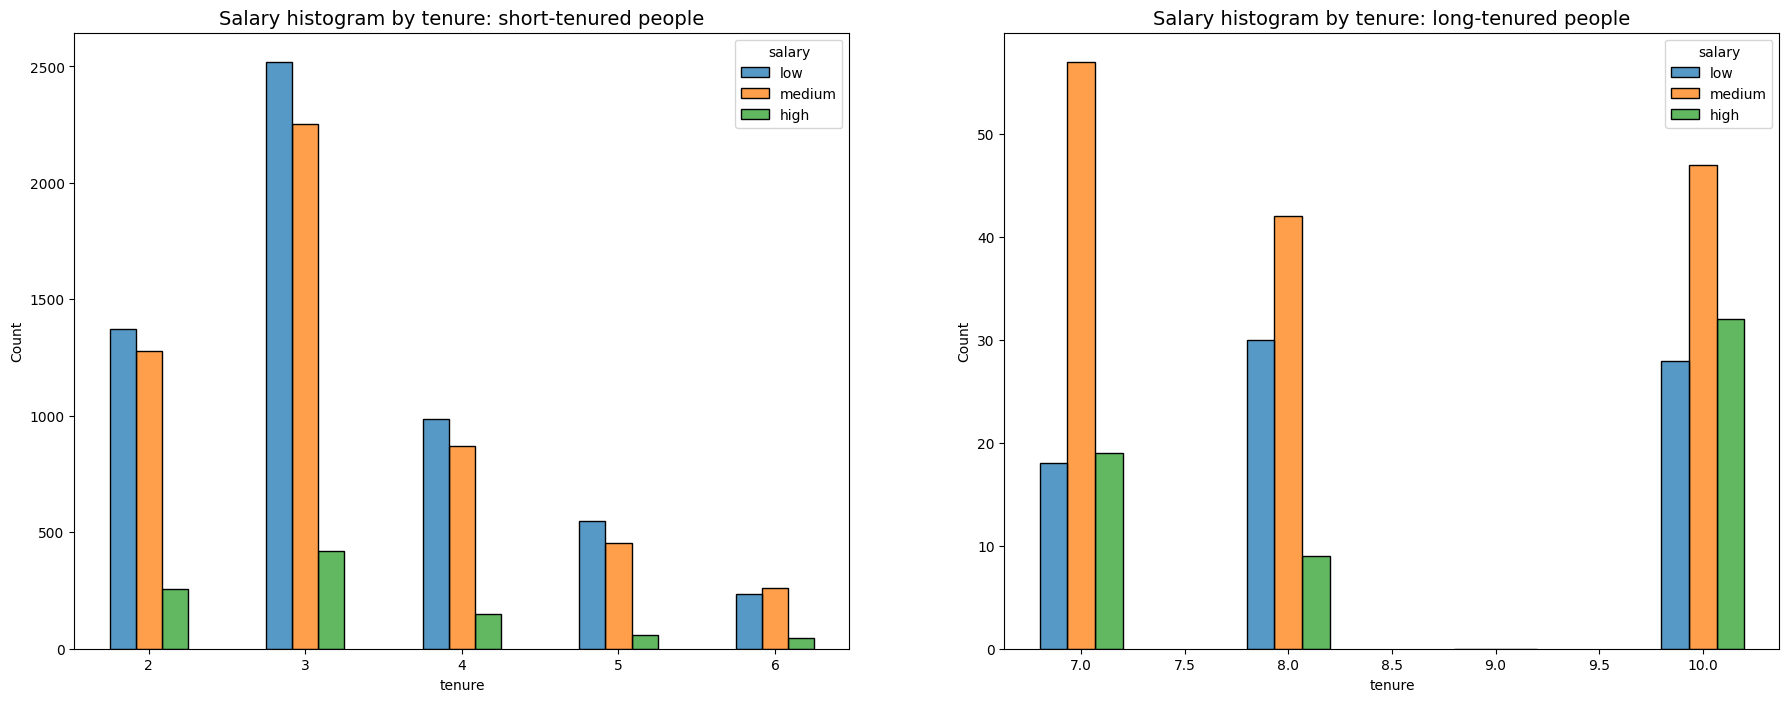

In [ ]:
### Charting the distribution of `tenure` for employees who stayed versus those who left, comparing the distribution of `tenure` for short-tenured employees (those with tenure less than 7 years) versus long-tenured employees (those with tenure greater than 6 years)
fig, ax = plt.subplots(1, 2, figsize = (22,8))

tenure_short = df[df['tenure'] < 7]

tenure_long = df[df['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

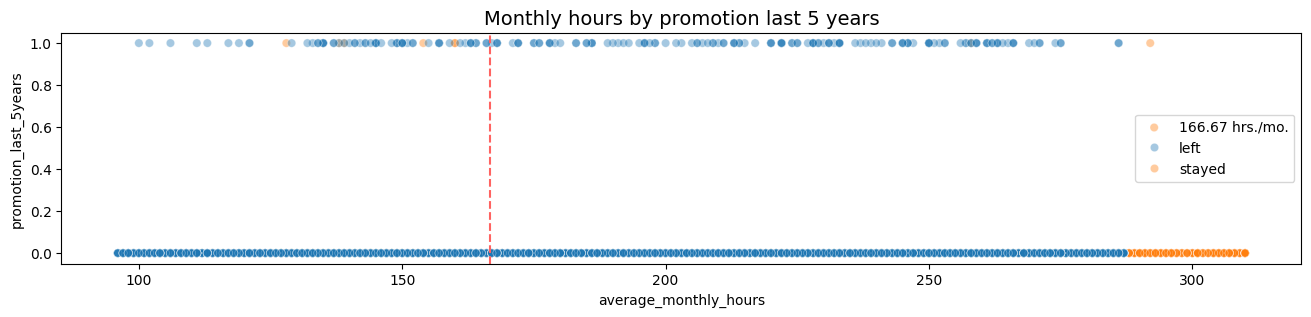

In [ ]:
### Monthly hours by promotion last 5 years, comparing employees who stayed versus those who left
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

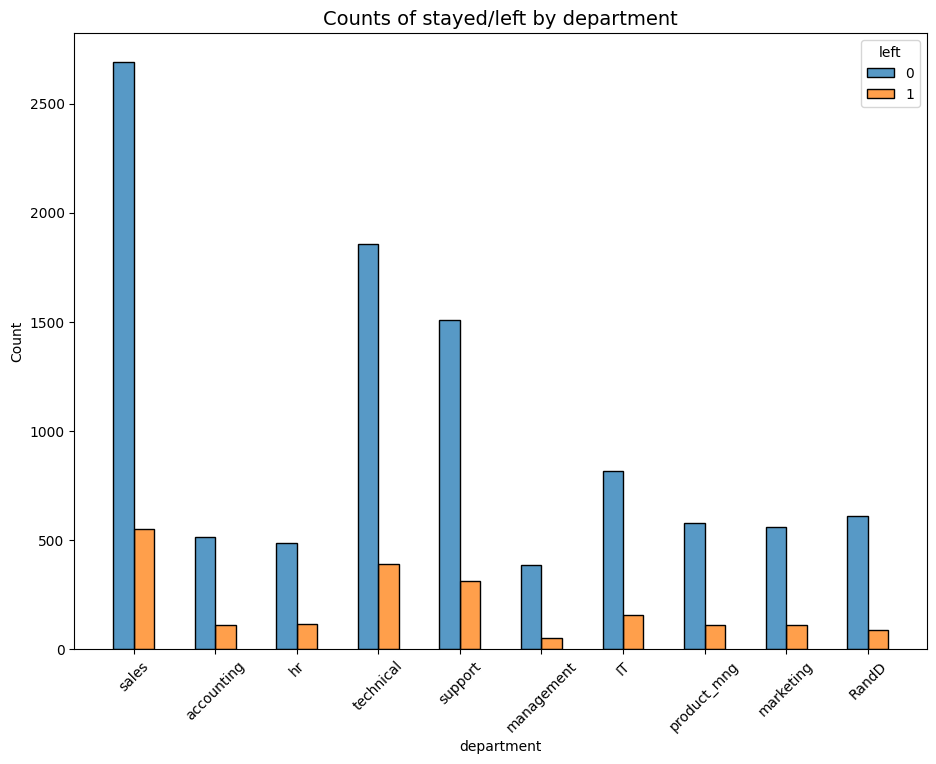

In [80]:
### Counts of stayed/left by department
plt.figure(figsize=(11,8))
sns.histplot(data=df, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);


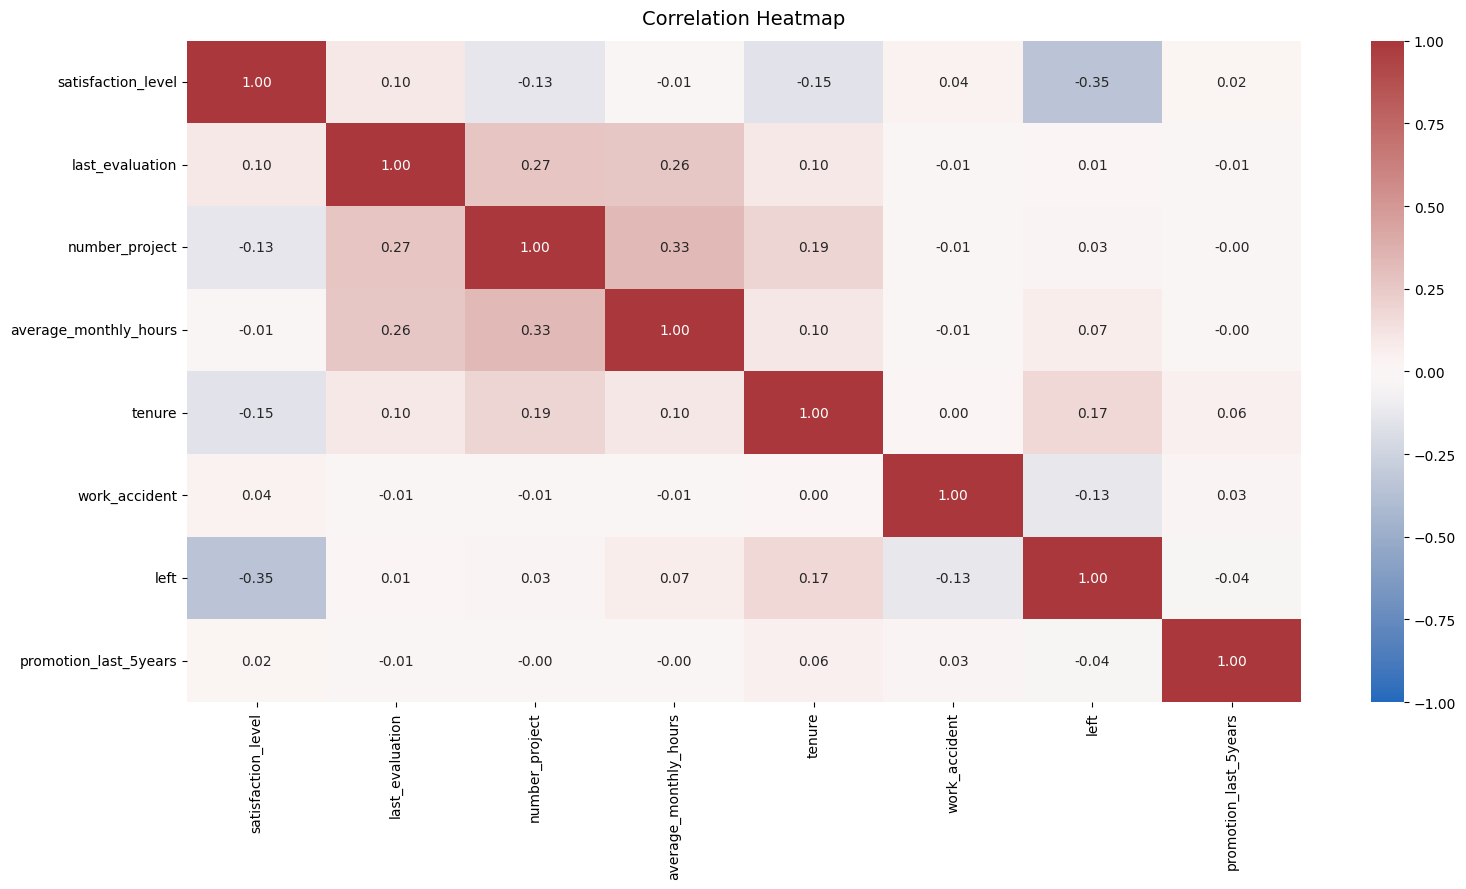

In [ ]:
### Correlation heatmap for numeric features
plt.figure(figsize=(16, 9))

corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    cmap='vlag'
)

plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()